# Segmented (contiguous-block) injection — VAE, step by step

**Derived from:** `07_segmented_injection/build_segmented_injection.py`,
`evaluate_segmented_injection.py`.

**Model:** clean-only (0% train contamination) VAE,
`phase3_vae/05_contamination_sweep/04_models/contam_0pct` (20 seeds,
threshold_95 per seed, inference only).

**Scoring: deterministic z_mean** (audit finding O2, `11_fable_review/`): z = z_mean at inference — no eps sample, no eval seed; threshold_95 is recomputed per seed as the 95th percentile of the deterministic error on the held-out val-benign set, matching the canonical `10_final_report` results (see `CHANGELOG.md`).

**Data:** the same flows as notebook 1
(`06_attack_type_analysis/test_with_attack_type.csv`), reordered — no
shuffling, no resampling, no new/synthetic flows — into one stream where
each attack type appears as a single contiguous block:
`benign -> apache_bench -> benign -> slowloris -> benign -> portscan -> benign`.

This notebook re-runs `build_sequence()` and the error-matrix logic live at
demo scale, and loads `07_segmented_injection`'s published 20-seed CSV/PNG
outputs for the authoritative final table and plot.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display as ipy_display

PROJECT_ROOT = "/Users/mustafa/Desktop/NIDS/IDS-Project"
ATTACK_TYPE_DIR = os.path.join(PROJECT_ROOT, "06_attack_type_analysis")
SEGMENTED_DIR = os.path.join(PROJECT_ROOT, "07_segmented_injection")
REPORT_DIR = os.path.join(PROJECT_ROOT, "10_final_report")
sys.path.insert(0, ATTACK_TYPE_DIR)
sys.path.insert(0, SEGMENTED_DIR)
import evaluate_by_attack_type as single
import build_segmented_injection as bld
import evaluate_segmented_injection as seg

# both bld/seg's dependency chain ends up calling matplotlib.use("Agg")
# (via evaluate_by_attack_type -> evaluate_contamination_sweep_extended.py);
# re-request the inline backend after those imports so plots render here.
%matplotlib inline

pd.set_option("display.width", 160)
print("Modules loaded:", bld.__file__, seg.__file__)

Modules loaded: /Users/mustafa/Desktop/NIDS/IDS-Project/07_segmented_injection/build_segmented_injection.py /Users/mustafa/Desktop/NIDS/IDS-Project/07_segmented_injection/evaluate_segmented_injection.py


## 1. How the block sequence is built

Re-runs `build_segmented_injection.build_sequence()` — the actual function, not a reimplementation — against the persisted `test_with_attack_type.csv`, without writing to `segmented_sequence.csv` (that stays untouched).

In [2]:
labeled_df = pd.read_csv(bld.LABELED_TEST_PATH)
sequence_live = bld.build_sequence(labeled_df, bld.DEFAULT_BLOCK_ORDER)
print(f"Built sequence: {len(sequence_live)} flows "
      f"({int((sequence_live['is_attack']==0).sum())} benign, {int((sequence_live['is_attack']==1).sum())} attack)")

layout = sequence_live.groupby(["segment_id", "segment_label"], sort=False).size().reset_index(name="n")
display(layout)

Built sequence: 9931 flows (6821 benign, 3110 attack)


,segment_id,segment_label,n
0,0,benign,1705
1,1,apache_bench,1487
2,2,benign,1705
3,3,slowloris,929
4,4,benign,1705
5,5,portscan,694
6,6,benign,1706


In [3]:
print("First 5 rows of the stream (benign segment 0):")
display(sequence_live.head())
print("\\nFirst 5 rows of the apache_bench block:")
display(sequence_live[sequence_live["segment_label"] == "apache_bench"].head())
print("\\nLast 5 rows of the apache_bench block:")
display(sequence_live[sequence_live["segment_label"] == "apache_bench"].tail())
print("\\nLast 5 rows of the stream (final benign segment):")
display(sequence_live.tail())

First 5 rows of the stream (benign segment 0):


,position,segment_id,segment_label,row_index,window_id,is_attack,ts
0,0,0,benign,1584,window_02_3pct,0,1.783695e+09
1,1,0,benign,36781,window_resampled_15pct,0,1.783695e+09
2,2,0,benign,680,window_02_3pct,0,1.783695e+09
3,3,0,benign,549,window_02_3pct,0,1.783696e+09
4,4,0,benign,36784,window_resampled_15pct,0,1.783696e+09


\nFirst 5 rows of the apache_bench block:


,position,segment_id,segment_label,row_index,window_id,is_attack,ts
1705,1705,1,apache_bench,9625,window_04_7pct,1,1.783703e+09
1706,1706,1,apache_bench,38166,window_resampled_15pct,1,1.783703e+09
1707,1707,1,apache_bench,9626,window_04_7pct,1,1.783703e+09
1708,1708,1,apache_bench,9627,window_04_7pct,1,1.783703e+09
1709,1709,1,apache_bench,38167,window_resampled_15pct,1,1.783703e+09


\nLast 5 rows of the apache_bench block:


,position,segment_id,segment_label,row_index,window_id,is_attack,ts
3187,3187,1,apache_bench,34553,window_08_22pct,1,1.783719e+09
3188,3188,1,apache_bench,34554,window_08_22pct,1,1.783719e+09
3189,3189,1,apache_bench,34555,window_08_22pct,1,1.783719e+09
3190,3190,1,apache_bench,34556,window_08_22pct,1,1.783719e+09
3191,3191,1,apache_bench,34557,window_08_22pct,1,1.783719e+09


\nLast 5 rows of the stream (final benign segment):


,position,segment_id,segment_label,row_index,window_id,is_attack,ts
9926,9926,6,benign,41603,window_resampled_15pct,0,1.783720e+09
9927,9927,6,benign,36699,window_08_22pct,0,1.783720e+09
9928,9928,6,benign,36703,window_08_22pct,0,1.783721e+09
9929,9929,6,benign,46494,window_resampled_20pct,0,1.783721e+09
9930,9930,6,benign,36704,window_08_22pct,0,1.783721e+09


In [4]:
persisted_sequence = pd.read_csv(seg.SEQUENCE_PATH)
match = (persisted_sequence["row_index"].values == sequence_live["row_index"].values).all()
print(f"Persisted segmented_sequence.csv: {persisted_sequence.shape}")
print("Freshly-built sequence matches the persisted file exactly (same row_index order):", match)

Persisted segmented_sequence.csv: (9931, 7)
Freshly-built sequence matches the persisted file exactly (same row_index order): True


## 2. VAE evaluation over the stream — building the error plot step by step

Uses a **5-seed demo backend** (`deterministic=True`: z = z_mean scoring, no eval seed — the stochastic `eval_seed_offset=950_000` convention is gone with the sampling itself; per-seed threshold_95 recalibrated on val-benign) against the persisted sequence's reconstructed features.

In [5]:
feature_cols = single.load_feature_cols()
ordered_df = seg.load_ordered_features(seg.SEQUENCE_PATH, feature_cols)
X = ordered_df[feature_cols].values.astype("float32")
y = ordered_df["is_attack"].values
print(f"Sequence: {len(ordered_df)} flows, {ordered_df['segment_id'].nunique()} segments")

demo_backend = single.VAEBackend(seeds=list(range(5)), deterministic=True)
error_matrix, thresholds = single.compute_error_matrix(X, backend=demo_backend)
for i in range(error_matrix.shape[0]):
    print(f"  seed={i}: mean error={error_matrix[i].mean():.5f}, threshold_95={thresholds[i]:.5f}")

mean_error = error_matrix.mean(axis=0)
mean_thr = float(np.mean(thresholds))
print(f"\\nMean threshold_95 across {len(demo_backend.seeds)} demo seeds: {mean_thr:.5f}")

Sequence: 9931 flows, 7 segments
  [VAEBackend] val-benign reference set for deterministic threshold_95: 653 flows


  seed=0: mean error=11605.51614, threshold_95=0.08979
  seed=1: mean error=11622.29285, threshold_95=0.08491
  seed=2: mean error=16500.05549, threshold_95=0.10089
  seed=3: mean error=9199.44842, threshold_95=0.09608
  seed=4: mean error=12073.42766, threshold_95=0.10465
\nMean threshold_95 across 5 demo seeds: 0.09526


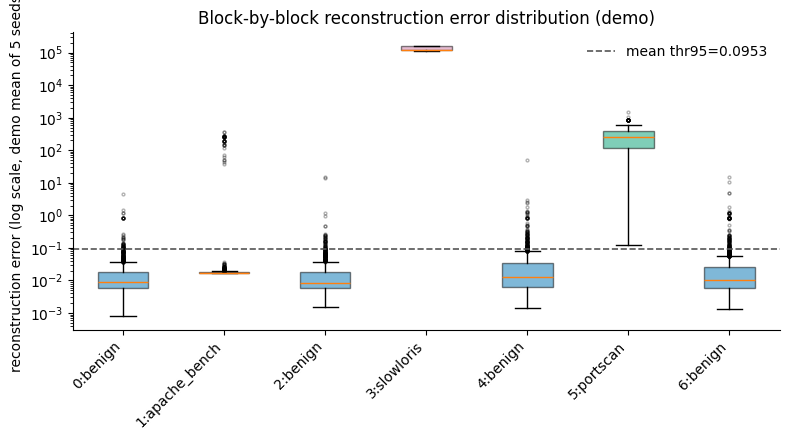

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
segment_labels_order = ordered_df.groupby("segment_id")["segment_label"].first().sort_index()
box_data = [mean_error[(ordered_df["segment_id"] == sid).values] for sid in segment_labels_order.index]
bp = ax.boxplot(box_data, tick_labels=[f"{sid}:{lab}" for sid, lab in segment_labels_order.items()],
                 patch_artist=True, showfliers=True, flierprops={"markersize": 2, "alpha": 0.3})
colors_by_label = {"benign": "#0072B2", "apache_bench": "#D55E00", "slowloris": "#CC79A7", "portscan": "#009E73"}
for patch, lab in zip(bp["boxes"], segment_labels_order.values):
    patch.set_facecolor(colors_by_label[lab]); patch.set_alpha(0.5)
ax.axhline(mean_thr, color="#555555", linestyle="--", linewidth=1.2, label=f"mean thr95={mean_thr:.4f}")
ax.set_yscale("log")
ax.set_ylabel("reconstruction error (log scale, demo mean of 5 seeds)")
ax.set_title("Block-by-block reconstruction error distribution (demo)")
plt.xticks(rotation=45, ha="right")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

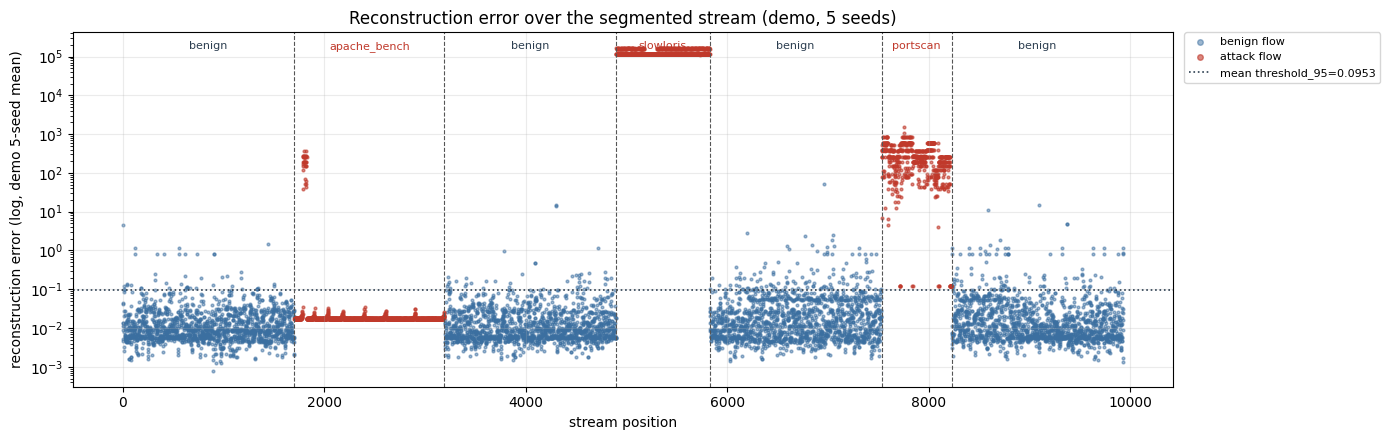

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.5))
positions = ordered_df["position"].values
benign_mask, attack_mask = (y == 0), (y == 1)
ax.scatter(positions[benign_mask], mean_error[benign_mask], s=4, color="#3b6fa0", alpha=0.5, label="benign flow")
ax.scatter(positions[attack_mask], mean_error[attack_mask], s=4, color="#c0392b", alpha=0.6, label="attack flow")
ax.axhline(mean_thr, color="#2c3e50", linestyle=":", linewidth=1.2, label=f"mean threshold_95={mean_thr:.4f}")
boundaries = ordered_df.groupby("segment_id")["position"].min().sort_index()
for seg_id, start_pos in boundaries.items():
    if seg_id > 0:
        ax.axvline(start_pos, color="#555555", linestyle="--", linewidth=0.8)
    lab = segment_labels_order[seg_id]
    mid = start_pos + (ordered_df[ordered_df["segment_id"] == seg_id]["position"].max() - start_pos) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.9, lab, ha="center", fontsize=8,
            color="#2c3e50" if lab == "benign" else "#c0392b")
ax.set_yscale("log")
ax.set_xlabel("stream position"); ax.set_ylabel("reconstruction error (log, demo 5-seed mean)")
ax.set_title("Reconstruction error over the segmented stream (demo, 5 seeds)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, markerscale=2, borderaxespad=0)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 3. Block-based recall/F1

Demo per-segment metrics (5 seeds), then the published 20-seed table/plot.

,segment_id,segment_label,fpr,recall
0,0,benign,0.028270,NaN
1,1,apache_bench,NaN,0.026227
2,2,benign,0.031906,NaN
3,3,slowloris,NaN,1.000000
4,4,benign,0.091613,NaN
5,5,portscan,NaN,1.000000
6,6,benign,0.067878,NaN


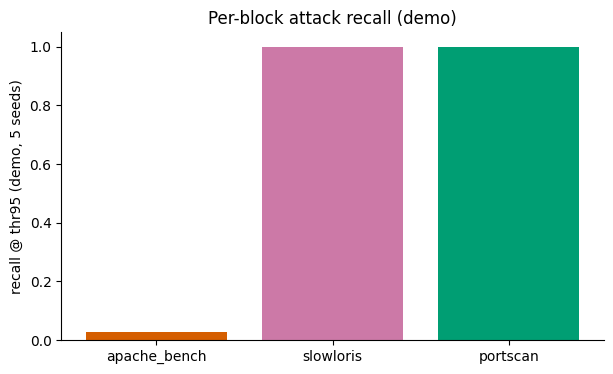

In [8]:
demo_rows = []
segments = ordered_df[["segment_id", "segment_label"]].drop_duplicates().sort_values("segment_id")
for i in range(error_matrix.shape[0]):
    errors_i = error_matrix[i]; thr_i = thresholds[i]
    pred_i = (errors_i > thr_i).astype(int)
    for _, s in segments.iterrows():
        mask = (ordered_df["segment_id"] == s["segment_id"]).values
        seg_y, seg_pred = y[mask], pred_i[mask]
        if s["segment_label"] == "benign":
            demo_rows.append({"segment_id": s["segment_id"], "segment_label": s["segment_label"],
                               "fpr": seg_pred.mean(), "recall": np.nan})
        else:
            demo_rows.append({"segment_id": s["segment_id"], "segment_label": s["segment_label"],
                               "fpr": np.nan, "recall": seg_pred.mean()})
demo_summary = pd.DataFrame(demo_rows).groupby(["segment_id", "segment_label"])[["fpr", "recall"]].mean().reset_index()
display(demo_summary)

fig, ax = plt.subplots(figsize=(7, 4))
attack_rows = demo_summary.dropna(subset=["recall"])
ax.bar(attack_rows["segment_label"], attack_rows["recall"],
       color=[colors_by_label[l] for l in attack_rows["segment_label"]])
ax.set_ylim(0, 1.05); ax.set_ylabel("recall @ thr95 (demo, 5 seeds)")
ax.set_title("Per-block attack recall (demo)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Published (20-seed) segmented results

Loaded from the canonical deterministic outputs in `10_final_report/03_segmented_injection/vae/`: `block_recall_f1_per_seed.csv` / `block_recall_f1.md`, plus the published error-vs-position plot (`error_plot.png`, computed the same way as above but over all 20 seeds, z_mean scoring).

,segment_id,segment_label,n,fpr_mean,fpr_std,recall_mean,recall_std,f1_mean,f1_std
0,0,benign,1705,0.032053,0.010966,NaN,NaN,NaN,NaN
1,1,apache_bench,1487,NaN,NaN,0.026227,0.000000,0.051114,0.000000
2,2,benign,1705,0.036129,0.010782,NaN,NaN,NaN,NaN
3,3,slowloris,929,NaN,NaN,1.000000,0.000000,1.000000,0.000000
4,4,benign,1705,0.093314,0.023856,NaN,NaN,NaN,NaN
5,5,portscan,694,NaN,NaN,0.998271,0.007733,0.999120,0.003934
6,6,benign,1706,0.069402,0.008288,NaN,NaN,NaN,NaN


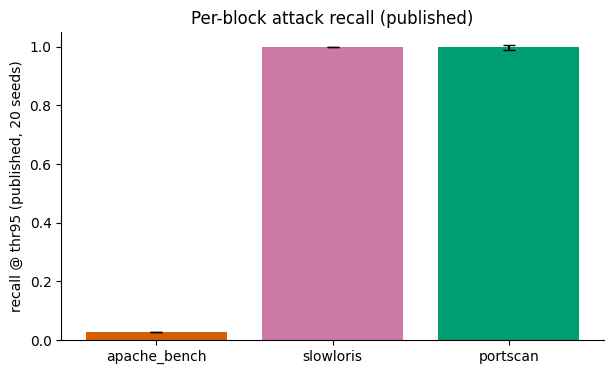

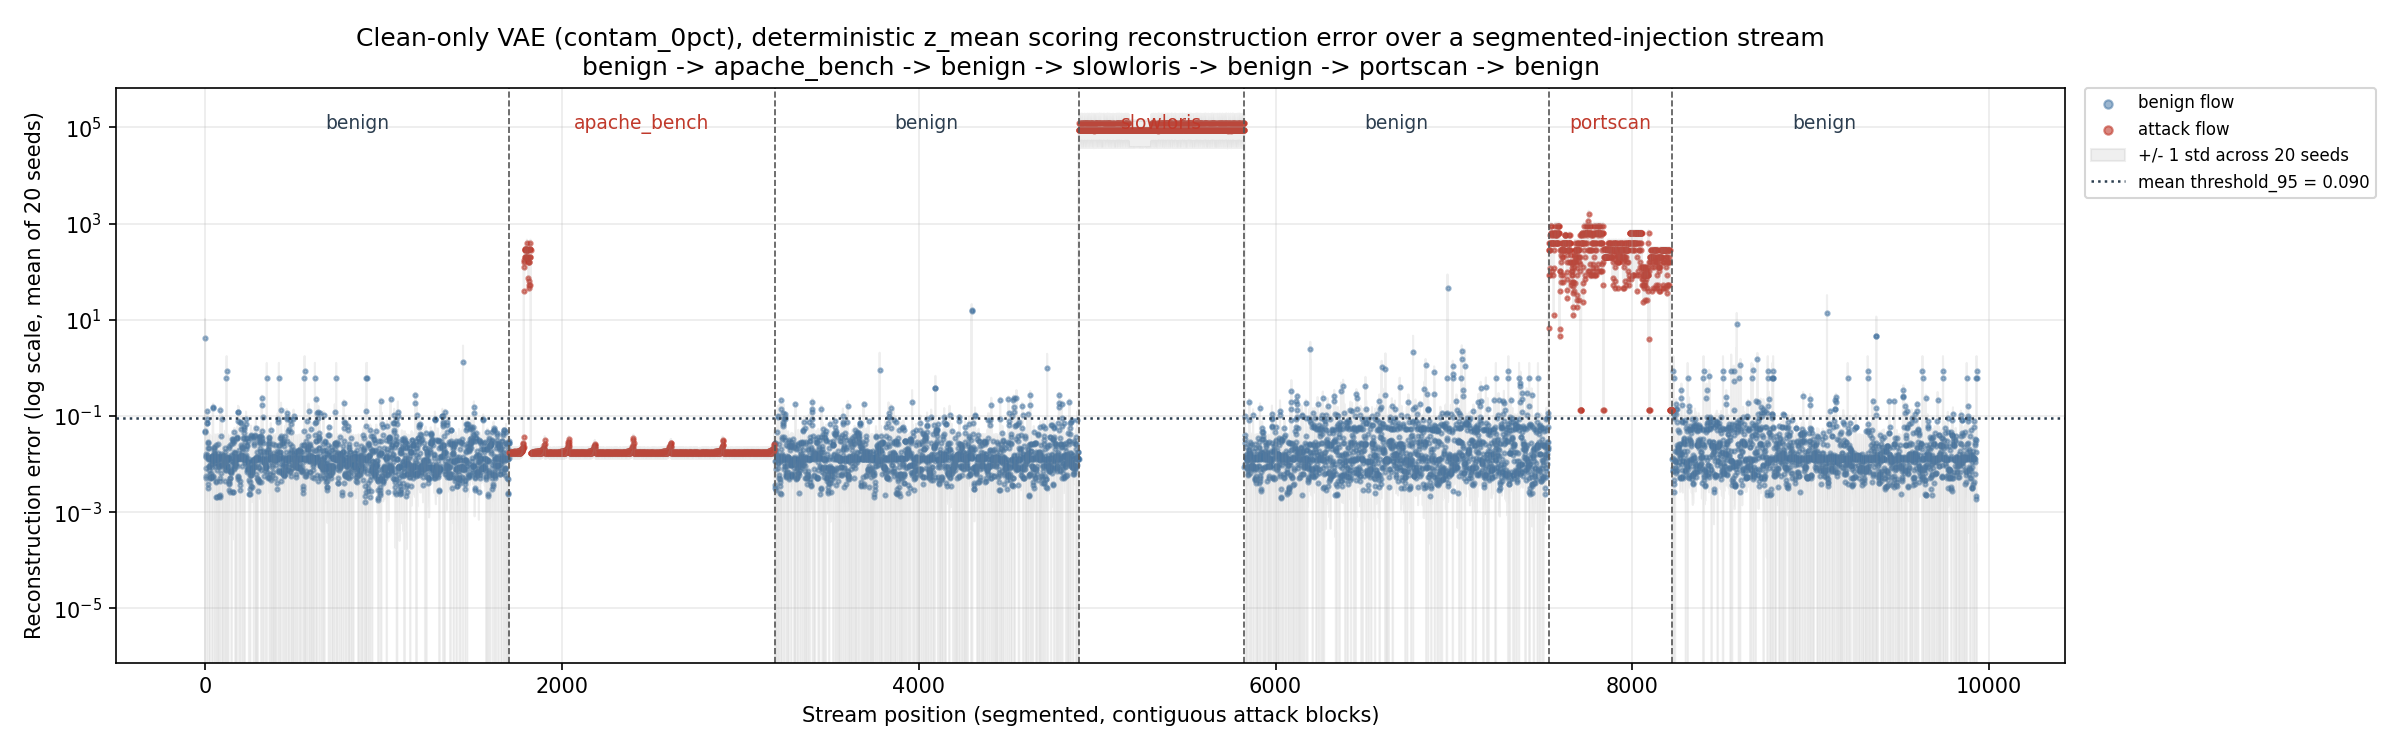

In [9]:
published_per_seed = pd.read_csv(os.path.join(REPORT_DIR, "03_segmented_injection", "vae", "block_recall_f1_per_seed.csv"))
published_summary = published_per_seed.groupby(["segment_id", "segment_label", "n"])[["fpr", "recall", "f1"]].agg(["mean", "std"])
published_summary.columns = [f"{c}_{s}" for c, s in published_summary.columns]
published_summary = published_summary.reset_index().sort_values("segment_id")
display(published_summary)

fig, ax = plt.subplots(figsize=(7, 4))
attack_rows = published_summary.dropna(subset=["recall_mean"])
ax.bar(attack_rows["segment_label"], attack_rows["recall_mean"], yerr=attack_rows["recall_std"],
       color=[colors_by_label[l] for l in attack_rows["segment_label"]], capsize=4)
ax.set_ylim(0, 1.05); ax.set_ylabel("recall @ thr95 (published, 20 seeds)")
ax.set_title("Per-block attack recall (published)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

ipy_display(Image(filename=os.path.join(REPORT_DIR, "03_segmented_injection", "vae", "error_plot.png")))